In [1]:
#!pip install geopandas

In [2]:
import geopandas as gpd
import pandas as pd
import folium
pd.set_option("display.max_columns", 20)
#pd.set_option("display.max_rows", 1000)

In [3]:
zones= gpd.read_file('taxi_zones/taxi_zones.shp')

In [4]:
zones.shape

(263, 7)

In [5]:
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [6]:
print(zones.crs)  # Projected System measured in metres

EPSG:2263


- `LocationID`: is the Taxizone ID
- `borough`: entire city
- `geometry`: essential part to pinpoint the location in a map
- `zone`: neighbourhood

All the locations of the Earth can be located by (Latitude, Longitude).
- Longitude: It basically tells how far is the place East/West of the `Prime Meridian`.
- Latitude: It basically tells how far is the place North/South of the `Equator`.

New York City:
1. Latitude:   40.7° North
2. Longitude:  74.0° West

This means New York is:

- 40.7 degrees north of the Equator
- 74 degrees west of the Prime Meridian

### Projected CRS (Coordinate Reference Systems):

It is a way of turning the Earth into a flat map that a computer can measure easily. 

By comparison **Geographic CRS**  indicates where a place on Earth is by:
1. Latitude
2. Longitude
3. Degrees

A Projected CRS uses **X** (left/right, usually East/West) and **Y-axis** (means up and down, usually North/South). Why do we need Projected CRS?

Latitude and Longitude are measured in degrees, so calculating an area directly is difficult. A Projected CRS converts the coordinates into units such as:

- metres
- feet

Thus, making it easier to calculate distance, area, length or nearby locations.

In [7]:
# Convert the Projected CRS to Geographic CRS:
# to_crs(): Transform geometries to a new coordinate reference system.

'''
EPSG: 4326 is a Geographic CRS (Longitude and latitude in degrees)

'''
zones= zones.to_crs(epsg= 4326)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [8]:
print(zones.crs)

EPSG:4326


A `Polygon` is one continuous, closed area. Imagine drawing a boundary around one park:

      __________
     /          \
    /    Park    \
    \            /
     \__________/

The `Closed Polygon` are a list of `(Latitude, Longitude)`.

Examples of Polygon features:

- one city district
- one park
- one lake
- one building
- one taxi zone
- one country with one continuous land area

A `MutliPolygon` is made of two or more separate polygons. Example would be an area having two islands, these pieces are physically disconnected, but they belong to the same feature. Thus, the are stored in MultiPolygon.

Examples include:

- a country containing several islands
- a district divided by water
- a taxi zone containing disconnected land or water areas
- an administrative area consisting of multiple separate pieces
     


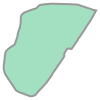

In [9]:
zones["geometry"][0]

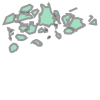

In [10]:
zones["geometry"][1]  # Multipolygon

### Analyzing Busiest Pickup Zones:

In [11]:
df= pd.read_csv("uber-raw-data-sep14.csv")
df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [12]:
# converting lat and lon to geometry:
#! pip install shapely

A **GeoDataFrame** object is a pandas.DataFrame that has one or more columns
containing geometry. In addition to the standard DataFrame constructor arguments,
GeoDataFrame also accepts the following keyword arguments:

##### Parameters
----------
- crs : value (optional)
    Coordinate Reference System of the geometry objects. Can be anything accepted by
    :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
    such as an authority string (eg "EPSG:4326") or a WKT string.
- geometry : str or array-like (optional)
    Value to use as the active geometry column.
    If str, treated as column name to use. If array-like, it will be
    added as new column named 'geometry' on the GeoDataFrame and set as the
    active geometry column.


**points_from_xy()**:
Generate GeometryArray of shapely Point geometries from x, y(, z) coordinates.
In case of geographic coordinates, it is assumed that longitude is captured by
``x`` coordinates and latitude by ``y``.

##### Parameters
----------
- x, y, z : iterable
- crs : value, optional
    Coordinate Reference System of the geometry objects. Can be anything accepted by
    :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
    such as an authority string (eg "EPSG:4326") or a WKT string.


----------------------------------

Why convert the Latitude and Longitude to point geometry?

- Latitude and Longitude tells us where the location is, but `Point geometry` gives `GeoPandas` an object on which it can perform spatial operations.

The Point geometry tells GeoPandas:

- this is one map location;
- longitude is its horizontal position;
- latitude is its vertical position;
- use this location in geographical calculations.

In [13]:
# Convert Coordinates into point geometries:
uber_geo= gpd.GeoDataFrame(df, geometry= gpd.points_from_xy(df['Lon'], df['Lat']), crs= "EPSG:4326")
uber_geo.head()

,Date/Time,Lat,Lon,Base,geometry
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512,POINT (-74.0021 40.2201)
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512,POINT (-74.0027 40.75)
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512,POINT (-73.9864 40.7559)
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512,POINT (-73.9889 40.745)
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512,POINT (-73.9444 40.8145)


In [14]:
zones.columns

Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='str')

**Spatial Joins** matches rows using their positions on a map based on the spatial relationship between their geometries.


In [15]:
uber_zones= gpd.sjoin(uber_geo, zones[['zone', 'LocationID', 'borough',
       'geometry']], how= "left", predicate= "within")

uber_zones.head()

,Date/Time,Lat,Lon,Base,geometry,index_right,zone,LocationID,borough
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512,POINT (-74.0021 40.2201),NaN,NaN,NaN,NaN
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512,POINT (-74.0027 40.75),245.0,West Chelsea/Hudson Yards,246.0,Manhattan
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512,POINT (-73.9864 40.7559),229.0,Times Sq/Theatre District,230.0,Manhattan
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512,POINT (-73.9889 40.745),233.0,Union Sq,234.0,Manhattan
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512,POINT (-73.9444 40.8145),41.0,Central Harlem North,42.0,Manhattan


In [16]:
zones[zones['zone']== "West Chelsea/Hudson Yards"]

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
245,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((-74.0044 40.76267, -74.0022 40.76173..."


`index_right` after the `spatial_join` is the original row index from the right-hand polygon GeoDataFrame.

In [17]:
uber_zones.shape

(1028136, 9)

In [18]:
uber_zones['zone'].nunique()  # 254 unique zones

254

In [19]:
uber_zones['zone'].value_counts() # Returns frequency of unique values in a column orderd by the frequency of the number of occurrences

zone
Midtown Center            32948
Union Sq                  31855
TriBeCa/Civic Center      31114
East Village              29009
East Chelsea              24533
                          ...  
New Dorp/Midland Beach        3
Broad Channel                 3
Arden Heights                 2
Great Kills                   1
Rossville/Woodrow             1
Name: count, Length: 254, dtype: int64

In [20]:
# Display top 15 busiest pick-up zones:
uber_zones['zone'].value_counts()[0:15]

zone
Midtown Center                   32948
Union Sq                         31855
TriBeCa/Civic Center             31114
East Village                     29009
East Chelsea                     24533
West Village                     24240
JFK Airport                      23567
Upper East Side South            21633
Midtown North                    21590
Murray Hill                      21525
Midtown East                     21276
Times Sq/Theatre District        21224
West Chelsea/Hudson Yards        21149
Meatpacking/West Village West    21091
Midtown South                    20934
Name: count, dtype: int64

In [21]:
uber_zones.columns

Index(['Date/Time', 'Lat', 'Lon', 'Base', 'geometry', 'index_right', 'zone',
       'LocationID', 'borough'],
      dtype='str')

In [22]:
uber_zones['borough'].value_counts()  

borough
Manhattan        760168
Brooklyn         146392
Queens            83610
Bronx              8638
EWR                7044
Staten Island       295
Name: count, dtype: int64

Manhattan area gets more uber pickups.

##### How many pickups occurred in every zone, separated by borough?

In [23]:
# Top 5 zones from each borough:

top_pickup_zones= (uber_zones.groupby(['borough', 'zone'])
    .size()
    .reset_index(name= "pickup_count")
    .sort_values(["borough", "pickup_count"], ascending= [True, False])
    .groupby("borough")
    .head(5))

print(top_pickup_zones)

           borough                                 zone  pickup_count
37           Bronx                       West Concourse          1216
28           Bronx  Riverdale/North Riverdale/Fieldston          1053
32           Bronx           Spuyten Duyvil/Kingsbridge           664
2            Bronx                              Belmont           580
15           Bronx                           Highbridge           476
100       Brooklyn            Williamsburg (North Side)         15217
89        Brooklyn                           Park Slope         10383
101       Brooklyn            Williamsburg (South Side)         10199
79        Brooklyn                           Greenpoint         10025
71        Brooklyn                    East Williamsburg          8070
103            EWR                       Newark Airport          7044
141      Manhattan                       Midtown Center         32948
158      Manhattan                             Union Sq         31855
155      Manhattan  

### Creating Bubble Map:

In [24]:
# Filtering top 20 pickup zones and storing it as a DataFrame:

uber_pickup_zones=(uber_zones['zone'].value_counts()[0:20]).reset_index()
uber_pickup_zones.columns= ['zone', 'pickup_count']
uber_pickup_zones

,zone,pickup_count
0,Midtown Center,32948
1,Union Sq,31855
2,TriBeCa/Civic Center,31114
3,East Village,29009
4,East Chelsea,24533
5,West Village,24240
6,JFK Airport,23567
7,Upper East Side South,21633
8,Midtown North,21590
9,Murray Hill,21525


In [25]:
zone_bubble_df= zones.merge(uber_pickup_zones, on= 'zone', how= 'inner') # keep all those data that matches both the table based on zone
zone_bubble_df.head(3)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pickup_count
0,48,0.043747,0.000094,Clinton East,48,Manhattan,"POLYGON ((-73.99118 40.75533, -73.99163 40.754...",18640
1,68,0.049337,0.000111,East Chelsea,68,Manhattan,"POLYGON ((-74.00202 40.74044, -74.00252 40.739...",24533
2,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((-73.98378 40.72154, -73.98382 40.721...",29009


In [26]:
# Convert the `geometry` to projected CRS: to get the centroid values from a flat map

zone_project_csr= zone_bubble_df.to_crs(epsg= 2263)
zone_project_csr.head(3)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pickup_count
0,48,0.043747,0.000094,Clinton East,48,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21...",18640
1,68,0.049337,0.000111,East Chelsea,68,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20...",24533
2,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20...",29009


The **centroid** calculates a representative central point for the polygon. That point becomes the bubble’s position.

In [27]:
zone_bubble_df['centroid']= (zone_project_csr['geometry'].centroid).to_crs(epsg= 4326)

zone_bubble_df.head(3)

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,pickup_count,centroid
0,48,0.043747,0.000094,Clinton East,48,Manhattan,"POLYGON ((-73.99118 40.75533, -73.99163 40.754...",18640,POINT (-73.98984 40.76225)
1,68,0.049337,0.000111,East Chelsea,68,Manhattan,"POLYGON ((-74.00202 40.74044, -74.00252 40.739...",24533,POINT (-73.99992 40.74843)
2,79,0.042625,0.000108,East Village,79,Manhattan,"POLYGON ((-73.98378 40.72154, -73.98382 40.721...",29009,POINT (-73.98594 40.72762)


In [36]:
base_map = folium.Map(
    location=[40.75, -73.97],
    zoom_start=12
)

In [37]:
for index, row in zone_bubble_df.iterrows():
    folium.CircleMarker(
        location= [row['centroid'].y, row['centroid'].x],
        radius=row['pickup_count']/2000,
        color= "crimson",
        fill= True,
        fill_opacity= 0.6,
        tooltip= (f'{row["zone"]}: {int(row["pickup_count"])} pickups')
    ).add_to(base_map)

In [38]:
base_map

### Marker Cluster Analysis

1. Rounding Lat and Lon to three decimal places to have a nearby location.
2. Custom Data Binning
3. FastMarkerCluster lib from folium.plugins

In [31]:
uber_geo.head(3)

,Date/Time,Lat,Lon,Base,geometry
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512,POINT (-74.0021 40.2201)
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512,POINT (-74.0027 40.75)
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512,POINT (-73.9864 40.7559)


In [32]:
uber_geo['Lat_bin']= uber_geo['Lat'].round(3)
uber_geo['Lon_bin']= uber_geo['Lon'].round(3)

In [42]:
# groupping by the lat and lon binning:
df_binning= uber_geo.groupby(['Lat_bin', 'Lon_bin'], as_index= False).size().sort_values(by= "size", ascending= False)
df_binning.head()

,Lat_bin,Lon_bin,size
4582,40.645,-73.782,7440
24312,40.774,-73.872,6038
4691,40.646,-73.777,4005
24311,40.774,-73.873,2684
18304,40.740,-74.006,2638


In [35]:
from folium.plugins import FastMarkerCluster

In [52]:
basemap_cluster = folium.Map(
    location=[40.75, -73.97],
    zoom_start=10
)

In [53]:
# Marker Cluster
FastMarkerCluster(df_binning[['Lat_bin', 'Lon_bin', 'size']]).add_to(basemap_cluster)

In [54]:
basemap_cluster